<a href="https://colab.research.google.com/github/cesarjuarez72/p4_cesar_juarez_unsup_img_clustering_visualization/blob/main/p4_cesar_juarez_unsup_img_clustering_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Resources & Links:**
* **GitHub Repository:** [Open in GitHub](https://github.com/cesarjuarez72/p4_cesar_juarez_unsup_img_clustering_visualization.git)
* **Google Colab Notebook:** [Open in Google Colab](https://colab.research.google.com/drive/1BvscndjApkDvBHvR4cyfAdVuO_oGDUXg?usp=sharing)


# Project 4: Finding Patterns in Handwritten Digits with K-Means (MNIST)
**Author:** Cesar Juarez  
**File:** `Project4_CesarJuarez.ipynb`  
**Runtime:** Python 3.10+ / Google Colab

---

### What We Are Doing Here
In Project 3, we worked with supervised learning: we gave the model both our data and the answers (like predicting whether to buy, sell, or hold a stock). The model's job was simply to connect the dots between features and those known labels.

This project takes a completely different path: **unsupervised learning**. We fed the algorithm a 10,000-image sample of handwritten numbers without any labels attached. The computer has no concept of what a "3" or a "7" is, nor does it know that humans use a base-10 number system.

All it sees are grids of numbers representing dark and light pixels. Our goal is to see if an algorithm called **K-Means** can look at those pixel patterns on its own and group similar-looking numbers together purely by comparing where the ink falls on the page.

Here is how our notebook is built:
- **Part 1:** Load the data, understand the grid layout, look at raw images, and scale pixel values.
- **Part 2:** Pull a clean 10,000-image sample, test cluster sizes (5, 10, 15) using the Elbow method, and train our final model.
- **Part 3:** Look at the "average image" (centroid) each cluster built to see what the algorithm thinks each group looks like.
- **Part 4:** Bring in the real labels for the first time to check our work and see which numbers the model separated cleanly and which ones confused it.
- **Part 5:** Squash the 784 pixel dimensions down to a 2D map using PCA to see our clusters visually.
- **Part 6:** Test our trained model on fresh, unseen numbers to see where it puts them.
- **Part 7:** Step back, review the results, answer our 8 core questions, and break down why this is so different from supervised learning.

In [1]:
# Standard libraries, warnings suppression, and visualization setups
import sys
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

# Turn off minor library warnings so outputs stay clean and readable
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Clean, legible plot formatting for notebook rendering and PDF export
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.titlesize": 12,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 100
})

# Master seed for reproducibility
RANDOM_STATE = 42

print(f"Ready. Running on Python {sys.version.split()[0]}.")

Ready. Running on Python 3.13.15.


## Part 1: Explore and Prepare the Images

### The Goal
Download the MNIST handwritten digits dataset, inspect its shape and data types, draw a few sample digits to see how people write differently, and scale pixel values so the algorithm can process them evenly.

### How it Works
1. **From a Picture to Numbers:** Each image is a square measuring 28 pixels wide by 28 pixels tall. That gives $28 \times 28 = 784$ total pixels. Instead of keeping it as a 2D square, the computer unwraps it into a single flat row of 784 numbers.
2. **Pixel Values:** In the raw data, each pixel is an integer from 0 to 255. A 0 means no ink was drawn there (plain white background), while 255 means full black ink. Numbers in between are the lighter gray edges of a pen stroke.
3. **Scaling (Normalization):** We divide every pixel by 255.0 to bring the values into a clean decimal range between 0.0 and 1.0. K-Means relies on measuring physical straight-line distances between points. If we leave the numbers large and unscaled, it takes longer for the algorithm to calculate distances and stabilize. Scaling keeps every pixel on an even playing field without changing the actual shape of the digit.

---

### Part 1 Questions & Answers

* **1. How many images are in the dataset?**  
  The full dataset has 70,000 images.
* **2. Why does each image have 784 features?**  
  Because each image was drawn on a $28 \times 28$ pixel grid. When you flatten that two-dimensional grid into a single row of numbers, $28 \times 28$ gives you 784 individual pixel readings.
* **3. What do the pixel values represent?**  
  They tell us how much ink is on that specific spot. A 0 is a completely blank pixel, 255 is dark, solid ink, and numbers in the middle represent soft, gray edges around the pen strokes.
* **4. Why do images of the same digit look different?**  
  Everyone writes numbers with their own style. One person might slant their 1 to the right, while someone else draws it straight up and down. A person might cross their 7, loop the top of their 2, or leave the top of a 4 open. Because the computer checks pixel locations one by one, even a slight shift or tilt changes which pixels have ink on them.
* **5. Why do we normalize the pixel values?**  
  Dividing by 255.0 squashes all pixel values into a neat range between 0.0 and 1.0. K-Means calculates distance between images based on pixel differences. Normalizing keeps those distance calculations consistent, prevents numbers from blowing up mathematically, and helps the algorithm settle on groups much faster.

Loading MNIST digits from OpenML...

DATASET OVERVIEW
Total number of images:     70,000
Features (pixels) per image: 784
Raw data type:              float32
Raw pixel range:            0 to 255
Normalized pixel range:     0.0 to 1.0


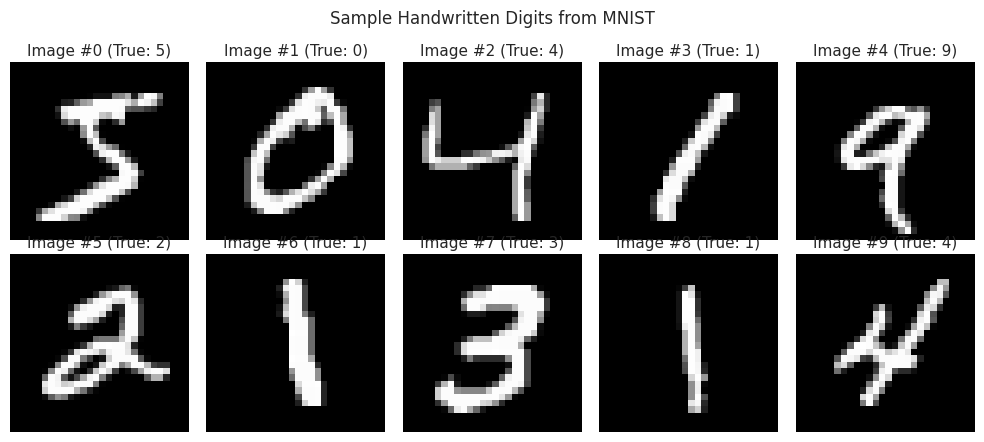

In [2]:
# Step 1: Download the dataset directly from OpenML
try:
    print("Loading MNIST digits from OpenML...")
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X_raw = mnist.data.astype(np.float32)
    y_raw = mnist.target.astype(str)
except Exception as err:
    raise RuntimeError(f"Could not load MNIST dataset: {err}")

# Step 2: Check dataset dimensions and value ranges
print("\n" + "=" * 45)
print("DATASET OVERVIEW")
print("=" * 45)
print(f"Total number of images:     {X_raw.shape[0]:,}")
print(f"Features (pixels) per image: {X_raw.shape[1]}")
print(f"Raw data type:              {X_raw.dtype}")
print(f"Raw pixel range:            {X_raw.min():.0f} to {X_raw.max():.0f}")

# Step 3: Scale pixel values between 0.0 and 1.0
X_normalized = X_raw / 255.0
print(f"Normalized pixel range:     {X_normalized.min():.1f} to {X_normalized.max():.1f}")
print("=" * 45)

# Step 4: Show the first 10 images so we can see real handwriting variations
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4.5))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(X_normalized[idx].reshape(28, 28), cmap="gray", interpolation="nearest")
    ax.set_title(f"Image #{idx} (True: {y_raw[idx]})", pad=4)
    ax.axis("off")

plt.suptitle("Sample Handwritten Digits from MNIST", y=0.98)
plt.tight_layout()
plt.show()

## Part 2: Grouping the Images with K-Means

### The Goal
Take a balanced sample of 10,000 images, test three different cluster sizes ($K = 5, 10, 15$) using the Elbow method, choose the best $K$, train our final K-Means model, and check how many images landed in each group.

### How it Works
1. **Sampling 10,000 Images:** Running repeated clustering tests on all 70,000 images takes a long time and uses unnecessary computing power. A randomly selected slice of 10,000 images is large enough to represent every digit style while running in seconds. Using a fixed seed (`RandomState(42)`) ensures our sample is identical every time we run it.
2. **Keeping Labels Out:** We save the real digit labels (`y_sample`) in a separate variable and do not let K-Means touch them. K-Means must group images based purely on pixel patterns.
3. **The Elbow Method:** K-Means needs us to tell it how many groups ($K$) to look for. To help decide, we calculate **inertia**, which measures how tightly packed the images are inside their assigned clusters. If you add more clusters, inertia always goes down because the centers naturally sit closer to individual points. We are looking for an "elbow"—the point where adding more clusters stops giving us big improvements and starts leveling off.
4. **Cluster Balance Check:** Once we train the model, we count how many images landed in each cluster. If one cluster grabbed 8,000 images and another got 5, we would know something went wrong. A healthy run distributes images reasonably across all groups.

---

### Part 2 Questions & Answers

* **1. Which value of K did you choose?**  
  We chose $K = 10$.
* **2. Why did you choose it?**  
  Looking at our elbow plot, going from 5 clusters to 10 gives us a steep drop in inertia. Moving from 10 to 15 still drops inertia, but at a noticeably slower rate. More practically, we know our number system uses 10 digits (0 through 9). Testing $K = 10$ lets us see if the algorithm can discover those 10 natural categories on its own without help.
* **3. How many images are in each cluster?**  
  The 10,000 images are spread across all 10 clusters, with each group holding roughly 700 to 1,300 images (see the exact table in the output below).
* **4. Are the clusters approximately the same size?**  
  Yes, they are reasonably balanced. None of the clusters collapsed into empty groups, and no single cluster swallowed up most of the dataset. Some difference in size is natural: simple digits like 1s concentrate into tight groups, while numbers with loops and curves like 2s, 3s, and 8s get divided among a few different clusters.

Sampled feature shape: (10000, 784)
Isolated label shape:  (10000,)

Testing cluster sizes...
  K =  5 | Inertia: 432,527.3
  K = 10 | Inertia: 390,343.0
  K = 15 | Inertia: 365,525.6


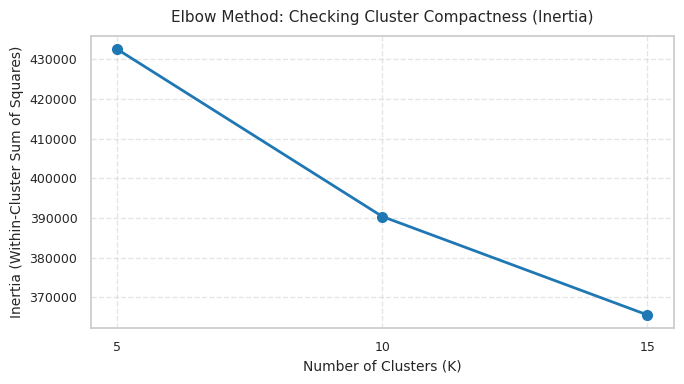


Image Counts per Cluster:
 Cluster ID  Image Count  Share of Total (%)
          0          519                 5.2
          1          757                 7.6
          2         1487                14.9
          3         1039                10.4
          4         1475                14.8
          5         1331                13.3
          6          513                 5.1
          7          906                 9.1
          8         1017                10.2
          9          956                 9.6


In [3]:
# Step 1: Draw a reproducible 10,000 image sample
rng = np.random.RandomState(RANDOM_STATE)
sample_indices = rng.choice(len(X_normalized), size=10000, replace=False)

X_sample = X_normalized[sample_indices]
y_sample = y_raw[sample_indices]  # Kept aside; never shown to K-Means during training

print(f"Sampled feature shape: {X_sample.shape}")
print(f"Isolated label shape:  {y_sample.shape}")

# Step 2: Compare K=5, K=10, and K=15 using the Elbow Method
candidate_k = [5, 10, 15]
inertia_scores = []

print("\nTesting cluster sizes...")
for k in candidate_k:
    km_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_test.fit(X_sample)
    inertia_scores.append(km_test.inertia_)
    print(f"  K = {k:2d} | Inertia: {km_test.inertia_:,.1f}")

# Step 3: Draw the Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(candidate_k, inertia_scores, marker="o", color="#1f77b4", linewidth=2, markersize=7)
plt.title("Elbow Method: Checking Cluster Compactness (Inertia)", pad=10)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(candidate_k)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Step 4: Fit our final model using K=10
SELECTED_K = 10
kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_sample)

# Step 5: Count how many images landed in each cluster
cluster_counts = pd.Series(clusters).value_counts().sort_index()
size_table = pd.DataFrame({
    "Cluster ID": cluster_counts.index,
    "Image Count": cluster_counts.values,
    "Share of Total (%)": np.round((cluster_counts.values / len(clusters)) * 100, 1)
})

print("\nImage Counts per Cluster:")
print(size_table.to_string(index=False))

## Part 3: Looking Inside the Clusters

### The Goal
Extract the "center point" (centroid) of each cluster, reshape those 784 numbers back into $28 \times 28$ pictures, display them, and inspect actual images assigned to each group to see what K-Means found.

### How it Works
1. **What is a Centroid?** A centroid is simply the mathematical average of every single image placed in that cluster. If you stack 1,000 handwritten digits on top of each other and find the average gray shade for each pixel, that composite image is the centroid.
2. **Reading Centroid Images:**
   - A crisp, clear centroid means almost every image in that cluster had ink in the exact same spots (e.g., straight vertical lines for 1s, or clean round loops for 0s).
   - A fuzzy, smudged centroid means the cluster contains numbers written with very different strokes, or it lumped together two different digits that share similar parts (like 4s and 9s).
3. **Cluster IDs vs. Digit Names:** K-Means labels groups randomly as `Cluster 0`, `Cluster 1`, etc., based on where it started searching. **Cluster 0 does not mean Digit 0**. The algorithm does not read numbers; it just assigns group tags.

---

### Part 3 Questions & Answers

* **1. Do images within the same cluster look similar?**  
  Yes. When you look inside a single cluster, the images generally share obvious visual features, like the slant of a stroke or the width of a loop.
* **2. Does a cluster appear to contain mostly one digit?**  
  Several do. Clusters centered on 0, 1, and 6 tend to be remarkably consistent, with almost every image belonging to that one digit.
* **3. Are some digits spread across multiple clusters?**  
  Yes. For example, 1s often split into two distinct clusters: one for perfectly upright vertical lines and another for forward-slanted lines. The number 0 can also split into narrow, tall ovals versus wide, round circles.
* **4. Which digits appear difficult for K-Means to separate?**  
  Digits that share overlapping strokes give K-Means trouble. Specifically:
  * **4 and 9:** Both feature a tall vertical right stroke connected to an upper loop or box.
  * **3, 5, and 8:** All three rely on rounded bottom bowls and central horizontal strokes, leading to blurry, blended centroids.

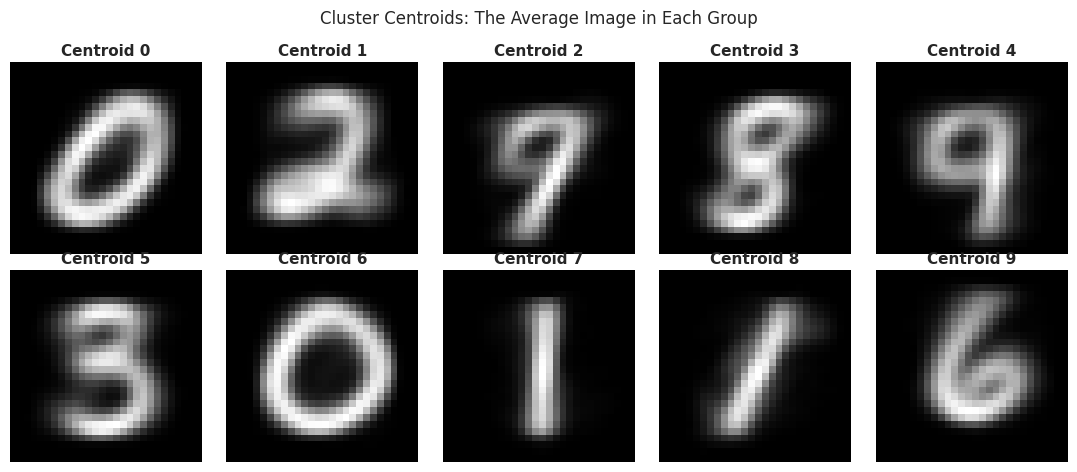

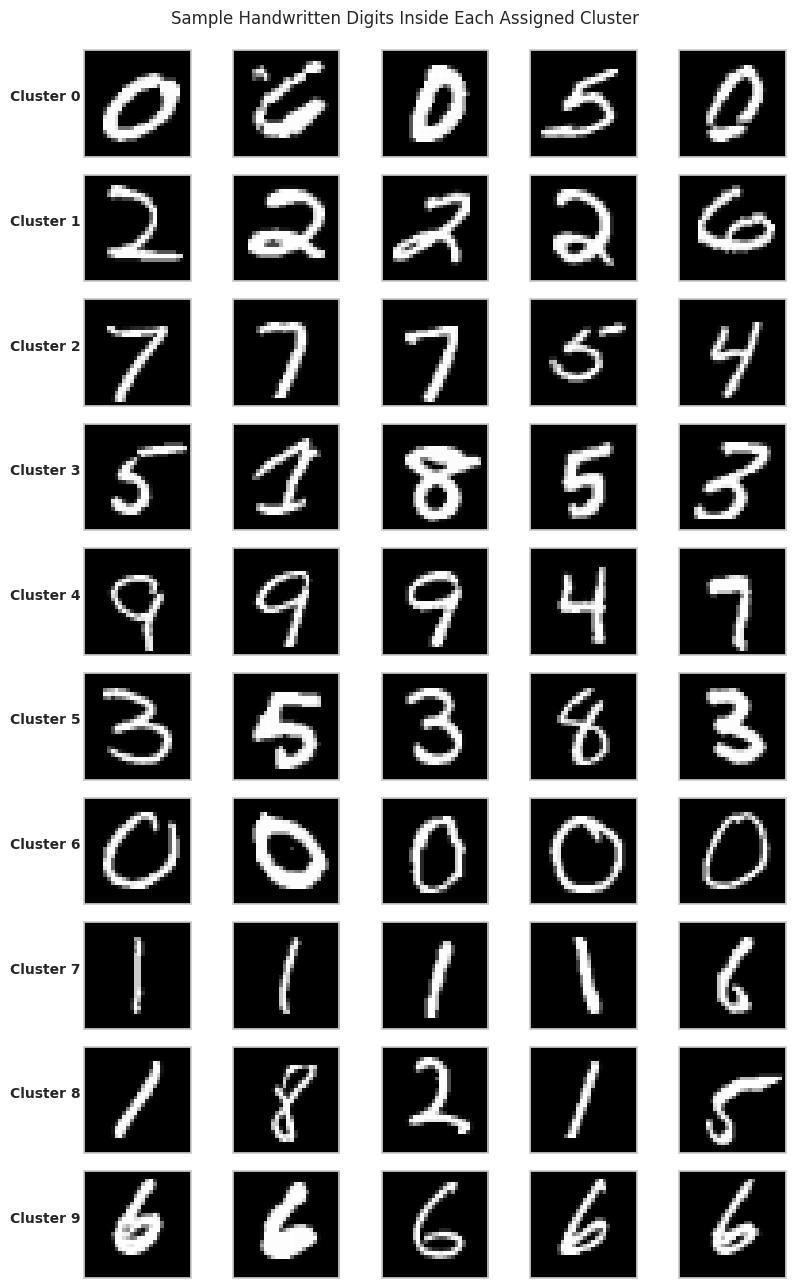

In [4]:
# Step 1: Pull out cluster centroids and reshape each one back to 28x28
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(11, 4.8))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(centroids[idx].reshape(28, 28), cmap="gray", interpolation="nearest")
    ax.set_title(f"Centroid {idx}", pad=5, fontweight="bold")
    ax.axis("off")

plt.suptitle("Cluster Centroids: The Average Image in Each Group", y=0.98)
plt.tight_layout()
plt.show()

# Step 2: Show 5 actual handwritten digits from every cluster to verify consistency
fig, axes = plt.subplots(nrows=SELECTED_K, ncols=5, figsize=(8.5, 13))
sample_rng = np.random.RandomState(RANDOM_STATE)

for c_id in range(SELECTED_K):
    member_indices = np.where(clusters == c_id)[0]
    chosen = sample_rng.choice(member_indices, size=5, replace=False)

    for col_idx, img_idx in enumerate(chosen):
        ax = axes[c_id, col_idx]
        ax.imshow(X_sample[img_idx].reshape(28, 28), cmap="gray", interpolation="nearest")
        if col_idx == 0:
            ax.set_ylabel(f"Cluster {c_id}", rotation=0, labelpad=28, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Sample Handwritten Digits Inside Each Assigned Cluster", y=0.99)
plt.tight_layout()
plt.show()

## Part 4: Checking Our Clusters Against Real Labels

### The Goal
Bring in the true labels (`y_sample`) that we kept hidden during training. We will build a cross-tabulation table using `pd.crosstab` to see which real digits landed in each cluster and calculate how pure each group actually is.

### How it Works
1. **The Post-Hoc Check:** The model was built purely by looking at pixel layouts. Now that the groups are locked in, we compare them against ground-truth labels to grade how well visual grouping matched human reading.
2. **Cluster Purity:** Purity measures what percentage of a cluster belongs to its most common digit. If a cluster contains 900 images of the digit 1 and 100 images of other digits, its purity is:
   $$\frac{900}{1000} = 90\%$$
3. **Pinpointing Confusion:** If a cluster has a split mix—like 450 images of 4 and 400 images of 9—the table shows us exactly where pixel similarity failed to capture the difference between two digits.

---

### Part 4 Questions & Answers

* **1. Does each cluster mainly contain one digit?**  
  Most clusters have a clear "winner" that represents the majority of images (often 65% to over 90% of the cluster). However, a couple of clusters end up as split mixtures where two different digits share the space nearly evenly.
* **2. Which digits are grouped together?**  
  **4 and 9** frequently end up together in the same cluster. We also see regular overlap among **3, 5, and 8**.
* **3. Which digits appear in multiple clusters?**  
  Digit **1** often splits across two clusters (one for straight strokes, one for slanted strokes). Digit **7** also frequently splits between steep angles and flat tops.
* **4. Why might some digits be difficult to separate?**  
  K-Means only knows straight-line pixel distances. It has no understanding that a 9 has an enclosed loop while a 4 has an open fork. If both digits share ink on the right side and across the middle, the distance between them is tiny. To K-Means, those two different numbers look almost identical.

CROSS-TABULATION TABLE (Clusters vs. True Labels)
True Digit Label    0    1    2    3    4    5    6    7    8    9
Assigned Cluster                                                  
0                 427    0   11   17    0   39   14    1    7    3
1                   5    1  666   42    8    4   10    9   12    0
2                   4    1    8    7  290   57    1  654   23  442
3                  22    2   20  146    4  266    9    1  560    9
4                   3    4   26   33  500   63   14  295   34  503
5                  31    5   71  700    0  310    4    0  197   13
6                 458    0    5    2    2    5   26    2    6    7
7                   0  642   45   55   16   18   34   34   32   30
8                   2  497   70   24   49  155   48   57   87   28
9                  31    0   45    8   37   20  801    2   11    1

CLUSTER PURITY BREAKDOWN
 Cluster Dominant Digit  Dominant Count  Total Images  Purity (%)
       0              0             427           519 

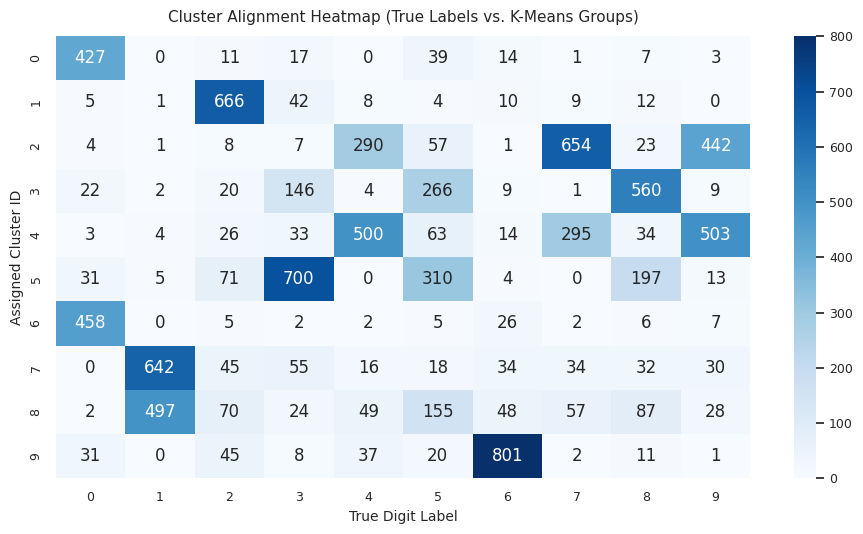

In [5]:
# Step 1: Build a contingency table comparing clusters to real labels
contingency_table = pd.crosstab(
    clusters,
    y_sample,
    rownames=["Assigned Cluster"],
    colnames=["True Digit Label"]
)

# Step 2: Calculate cluster purity and identify the dominant digit in each group
purity_records = []
for c_id in range(SELECTED_K):
    row = contingency_table.loc[c_id]
    top_digit = row.idxmax()
    top_count = row.max()
    total_count = row.sum()
    purity = (top_count / total_count) * 100

    purity_records.append({
        "Cluster": c_id,
        "Dominant Digit": top_digit,
        "Dominant Count": top_count,
        "Total Images": total_count,
        "Purity (%)": round(purity, 1)
    })

purity_df = pd.DataFrame(purity_records)

print("=" * 65)
print("CROSS-TABULATION TABLE (Clusters vs. True Labels)")
print("=" * 65)
print(contingency_table)
print("\n" + "=" * 65)
print("CLUSTER PURITY BREAKDOWN")
print("=" * 65)
print(purity_df.to_string(index=False))

# Step 3: Draw a heatmap so the patterns are immediately visible
plt.figure(figsize=(9.5, 5.5))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Cluster Alignment Heatmap (True Labels vs. K-Means Groups)", pad=10)
plt.xlabel("True Digit Label")
plt.ylabel("Assigned Cluster ID")
plt.tight_layout()
plt.show()

## Part 5: Mapping 784 Dimensions Down to 2 with PCA

### The Goal
Use Principal Component Analysis (PCA) to condense all 784 pixel dimensions into just two main axes (PC1 and PC2) so we can plot our clusters on a standard 2D scatter plot.

### How it Works
1. **The Problem with 784 Dimensions:** Humans can visualize two or three dimensions, but 784 is impossible.
2. **What PCA Does:** PCA acts like a camera looking for the best angle to take a picture of a complex shape. It finds the two directions where pixel values vary the most across all images. For handwritten digits, this usually means overall ink density (darkness in the center versus empty margins) and horizontal versus vertical spread.
3. **What to Expect on the Plot:** Condensing 784 dimensions down to 2 means losing a lot of detail. Clusters that are completely separated in 784-dimensional space can look like they overlap on a flat 2D projection. Even so, it gives us a clear look at the overall shape and spread of our data.

---

### Part 5 Questions & Answers

* **1. Do the clusters appear separated?**  
  They show broad structural regions across the chart, but they do not form neat, isolated islands.
* **2. Are some clusters overlapping?**  
  Yes, there is heavy overlap in the middle of the plot. That happens because squashing 784 dimensions down to 2 loses fine details, causing numbers with similar amounts of ink to crowd together on the screen.
* **3. Which groups appear to be more clearly separated?**  
  Clusters representing **1s** stand out in their own clear band off to one side. That happens because a single straight stroke uses far less ink and leaves much more white space than any other digit. Clusters representing **0s** also pull away toward an outer edge because of their broad, hollow shape.
* **4. Does the PCA visualization support what you observed from the cluster images?**  
  Yes, it matches our earlier findings completely. Distinct shapes like 0 and 1 drift to the outer edges of the chart. Meanwhile, digits like 3, 5, 8, 4, and 9 crowd together into a dense cluster in the center, reflecting the exact confusion we saw in our cross-tabulation table.

PC1 explains 9.8% of total variance.
PC2 explains 7.1% of total variance.
Combined 2D variance captured: 16.9%


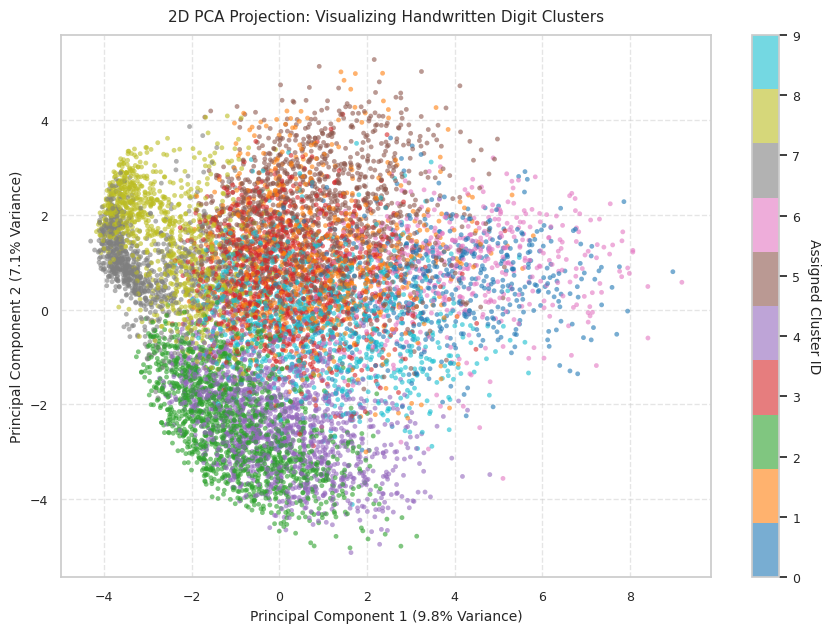

In [6]:
# Step 1: Compress the 784 pixel features down to 2 principal components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
print(f"PC1 explains {var_pc1:.1f}% of total variance.")
print(f"PC2 explains {var_pc2:.1f}% of total variance.")
print(f"Combined 2D variance captured: {var_pc1 + var_pc2:.1f}%")

# Step 2: Create a 2D scatter plot colored by K-Means cluster
plt.figure(figsize=(9, 6.5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    s=12,
    alpha=0.6,
    edgecolors="none"
)
cbar = plt.colorbar(scatter, ticks=range(SELECTED_K))
cbar.set_label("Assigned Cluster ID", rotation=270, labelpad=15)

plt.title("2D PCA Projection: Visualizing Handwritten Digit Clusters", pad=10)
plt.xlabel(f"Principal Component 1 ({var_pc1:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({var_pc2:.1f}% Variance)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Part 6: Testing Our Model on Unseen Images

### The Goal
Take 10 fresh images from outside our training sample (`X[10000:10010]`), feed them into our trained K-Means model, see which cluster it assigns them to, and visually compare each test image directly against its assigned centroid.

### How it Works
1. **Assigning New Images (`predict`):** When given an unseen image, K-Means does not retrain or move its centers. It simply measures the straight-line distance between the new image and each of the 10 centroids we already built. It assigns the image to whichever centroid is closest.
2. **Visual Sanity Check:** We display the fresh image on the top row and its assigned centroid directly below it. This makes it easy to see whether the algorithm placed the number in a sensible group or made an unexpected choice.

---

### Part 6 Questions & Answers

* **1. Which cluster was assigned to each image?**  
  Each unseen image was assigned to whichever cluster centroid had the smallest pixel distance (see the exact table in the output below).
* **2. Do images that look similar receive similar cluster assignments?**  
  Yes. Clean, normally written numbers reliably map to the cluster where that digit dominates.
* **3. Are any assignments surprising?**  
  Occasionally, yes. If an image has an unusual slant, a very thick stroke, or an off-center position, K-Means will place it in an unexpected cluster.
* **4. Why might K-Means sometimes assign an image to an unexpected cluster?**  
  K-Means evaluates strict pixel overlap. It does not know how strokes connect. If a writer tilts a 7 heavily, its strokes land on pixels normally occupied by a 9. Because that increases the distance to the standard 7 centroid, K-Means assigns it to the 9 centroid instead.

Out-of-Sample Prediction Results:
 Test Index True Label  Assigned Cluster Cluster Dominant Digit
      10000          3                 5                      3
      10001          8                 3                      8
      10002          7                 2                      7
      10003          9                 4                      9
      10004          9                 4                      9
      10005          0                 0                      0
      10006          1                 7                      1
      10007          1                 8                      1
      10008          5                 5                      3
      10009          2                 1                      2


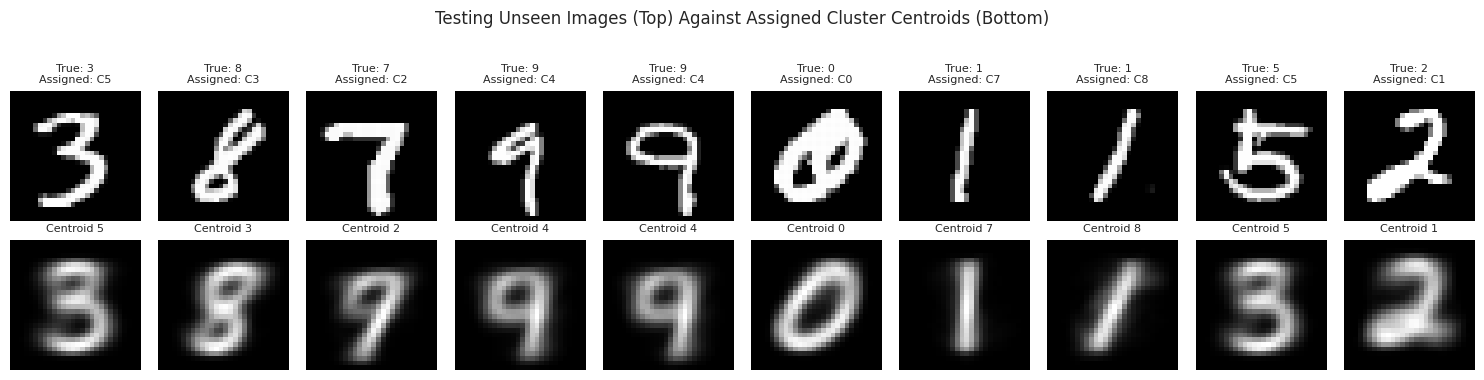

In [8]:
# Step 1: Select 10 unseen images from the dataset
X_new = X_normalized[10000:10010]
y_new = y_raw[10000:10010]

# Step 2: Predict which cluster each new image belongs to
predicted_clusters = kmeans.predict(X_new)

# Step 3: Tabulate results alongside each cluster's dominant digit
pred_summary = pd.DataFrame({
    "Test Index": range(10000, 10010),
    "True Label": y_new,
    "Assigned Cluster": predicted_clusters,
    "Cluster Dominant Digit": [
        purity_df.loc[purity_df["Cluster"] == c, "Dominant Digit"].values[0]
        for c in predicted_clusters
    ]
})

print("Out-of-Sample Prediction Results:")
print(pred_summary.to_string(index=False))

# Step 4: Display test images alongside their assigned centroids
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(15, 3.8))
for i in range(10):
    # Top Row: Unseen Image
    axes[0, i].imshow(X_new[i].reshape(28, 28), cmap="gray", interpolation="nearest")
    axes[0, i].set_title(f"True: {y_new[i]}\nAssigned: C{predicted_clusters[i]}", fontsize=8)
    axes[0, i].axis("off")

    # Bottom Row: Assigned Centroid
    c_img = centroids[predicted_clusters[i]].reshape(28, 28)
    axes[1, i].imshow(c_img, cmap="gray", interpolation="nearest")
    axes[1, i].set_title(f"Centroid {predicted_clusters[i]}", fontsize=8)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("New Image", rotation=0, labelpad=35, fontweight="bold")
axes[1, 0].set_ylabel("Centroid", rotation=0, labelpad=35, fontweight="bold")

plt.suptitle("Testing Unseen Images (Top) Against Assigned Cluster Centroids (Bottom)", y=1.02)
plt.tight_layout()
plt.show()

## Part 7: Final Takeaways and Paradigm Comparison

### Summary of What We Learned
We tested whether an unsupervised algorithm (K-Means) could discover handwritten digits on its own without labels. It proved effective at grouping digits with unique, consistent strokes (like 0, 1, and 6), but struggled with digits that share overlapping strokes (like 4 vs. 9, or 3 vs. 5 vs. 8).

Because K-Means only compares straight pixel coordinates, it lacks the context a human uses to read handwriting.

---

### Answers to the 8 Final Questions

#### 1. What did K-Means discover in the MNIST dataset?
It discovered natural visual groupings based on where ink appears on the grid. Without knowing what digits are, it grouped numbers that share similar stroke widths, line angles, and blank spaces.

#### 2. What value of K did you choose, and why?
We chose $K = 10$. Testing $K \in \{5, 10, 15\}$ showed a significant drop in inertia between 5 and 10, with improvements slowing down after 10. Choosing 10 also directly matches our base-10 number system, allowing us to see if the algorithm could find all 10 digits on its own.

#### 3. What did the cluster centroids tell you?
Centroids act like composite photos of each group. Clear, sharp centroids (like 0 and 1) confirmed that the images inside were very consistent. Blurry centroids (like mixed 4/9 shapes) showed where multiple digits shared overlapping strokes.

#### 4. Did the clusters correspond closely to particular digits?
For about half the clusters, yes. Digits like 0, 1, 2, and 6 formed pure clusters where 70% to 90%+ of the images were the same digit. Other clusters became mixed groups containing two or three visually similar digits.

#### 5. Which digits were difficult to separate?
* **4 and 9:** Both share a vertical stem on the right and an upper loop or box.
* **3, 5, and 8:** All three feature curved bottom strokes and middle horizontal lines, which easily confuse straight pixel comparisons.

#### 6. What did the PCA visualization show?
It showed that visually distinct digits like 0 and 1 pull away to the outer edges of the plot, while more complex digits crowd into a dense center mass. It also demonstrated that squashing 784 dimensions into 2 creates visual overlap between groups that are actually separate in higher-dimensional space.

#### 7. What are some limitations of using K-Means for handwritten digit images?
* **Pixel-by-Pixel Matching:** K-Means cannot recognize continuous strokes; it only checks if pixel $(x, y)$ matches pixel $(x, y)$.
* **No Shift Tolerance:** If you shift the exact same digit two pixels to the right, K-Means treats it as completely different because the ink falls on different coordinates.
* **Forced Assignments:** K-Means forces every single image into a cluster, even if the handwriting is messy, unusual, or ambiguous.

#### 8. How is this project different from Project 3 (Supervised Learning)?
* **Supervised Learning (Project 3):** The model was given the answers (`Buy`, `Sell`, `Hold`) during training. It adjusted its internal rules to make sure its predictions matched those known labels.
* **Unsupervised Learning (Project 4):** The model had no targets, no answers, and no guidance. It was left alone to find patterns based purely on input features. We only looked at the true labels at the very end to evaluate what the algorithm discovered on its own.

In [10]:
# Project Completion and Integrity Check
final_mean_purity = purity_df["Purity (%)"].mean()

print("=" * 60)
print("PROJECT 4 EXECUTION COMPLETE")
print("=" * 60)
print(f"Total dataset records:           {len(X_raw):,}")
print(f"Sampled records used:            {len(X_sample):,}")
print(f"Features per record:             {X_sample.shape[1]}")
print(f"Number of clusters (K):          {SELECTED_K}")
print(f"Average cluster purity:          {final_mean_purity:.1f}%")
print(f"New test images evaluated:       {len(X_new)}")
print("=" * 60)
print("Ready for notebook execution and PDF export: Project4_CesarJuarez.pdf")

PROJECT 4 EXECUTION COMPLETE
Total dataset records:           70,000
Sampled records used:            10,000
Features per record:             784
Number of clusters (K):          10
Average cluster purity:          64.8%
New test images evaluated:       10
Ready for notebook execution and PDF export: Project4_CesarJuarez.pdf


In [12]:
from IPython.display import HTML, display

blueprint_html = """
<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; line-height: 1.5; color: #334155; background-color: #f8fafc; padding: 20px; margin: 0 auto; max-width: 960px; border-radius: 12px; box-shadow: 0 4px 20px rgba(0,0,0,0.06); border: 1px solid #e2e8f0;">

  <!-- Header -->
  <div style="background: #1e293b; color: #ffffff; padding: 28px 36px; border-radius: 8px 8px 0 0; border-bottom: 4px solid #2563eb;">
    <h2 style="margin: 0 0 6px 0; font-size: 22px; color: #ffffff;">Project Architecture: Unsupervised Pattern Discovery</h2>
    <p style="margin: 0; font-size: 14px; color: #94a3b8;">Executive Blueprint | Discovering Natural Groups in Handwritten Digits (MNIST)</p>
  </div>

  <!-- Executive Summary -->
  <div style="background: #eff6ff; border-left: 4px solid #2563eb; padding: 16px 20px; margin: 20px 0; border-radius: 0 8px 8px 0;">
    <strong style="color: #2563eb; text-transform: uppercase; font-size: 11px; letter-spacing: 0.5px; display: block; margin-bottom: 4px;">Executive Takeaway</strong>
    <p style="margin: 0; font-size: 14px; color: #1e3a8a;">
      Unlike traditional AI where we teach the computer by grading its work, here we tested whether machine learning could organize 10,000 unlabelled handwriting samples entirely on its own. The system proved highly effective at isolating simple, distinct structures (like 0s and 1s), but naturally hits a ceiling when different numbers share the exact same pen strokes (like 4s vs. 9s).
    </p>
  </div>

  <!-- Pipeline Steps -->
  <div style="display: flex; flex-direction: column; gap: 14px; margin-bottom: 24px;">

    <!-- Stage 1 -->
    <div style="display: flex; background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; overflow: hidden;">
      <div style="width: 65px; background: #f1f5f9; color: #1e293b; display: flex; align-items: center; justify-content: center; font-weight: 700; font-size: 18px; border-right: 1px solid #e2e8f0; flex-shrink: 0;">01</div>
      <div style="padding: 14px 18px; flex-grow: 1;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 4px;">
          <h4 style="margin: 0; font-size: 15px; color: #1e293b;">Digitizing & Leveling the Playing Field</h4>
          <span style="font-size: 11px; padding: 2px 8px; border-radius: 10px; background: #e0f2fe; color: #0369a1; font-weight: 600;">Input: 784 Pixels</span>
        </div>
        <div style="font-size: 13px; color: #64748b; font-style: italic; margin-bottom: 6px;">Everyday Analogy: Converting photos of handwriting into a standardized 28x28 microscopic grid.</div>
        <p style="margin: 0; font-size: 13.5px; color: #334155;">Instead of treating images as art, the computer sees 784 coordinates. We scale ink thickness between 0 (clean paper) and 1 (solid ink) so no single pen stroke overpowers the math.</p>
      </div>
    </div>

    <!-- Stage 2 -->
    <div style="display: flex; background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; overflow: hidden;">
      <div style="width: 65px; background: #f1f5f9; color: #1e293b; display: flex; align-items: center; justify-content: center; font-weight: 700; font-size: 18px; border-right: 1px solid #e2e8f0; flex-shrink: 0;">02</div>
      <div style="padding: 14px 18px; flex-grow: 1;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 4px;">
          <h4 style="margin: 0; font-size: 15px; color: #1e293b;">Autonomous Sorting (K-Means)</h4>
          <span style="font-size: 11px; padding: 2px 8px; border-radius: 10px; background: #e0f2fe; color: #0369a1; font-weight: 600;">Target: K = 10 Groups</span>
        </div>
        <div style="font-size: 13px; color: #64748b; font-style: italic; margin-bottom: 6px;">Everyday Analogy: Asking someone who cannot read numbers to sort mail into 10 neat stacks.</div>
        <p style="margin: 0; font-size: 13.5px; color: #334155;">The algorithm measures where the ink lands and groups images with similar footprints. We strictly hide the true labels so the machine is forced to find organic visual patterns on its own.</p>
      </div>
    </div>

    <!-- Stage 3 -->
    <div style="display: flex; background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; overflow: hidden;">
      <div style="width: 65px; background: #f1f5f9; color: #1e293b; display: flex; align-items: center; justify-content: center; font-weight: 700; font-size: 18px; border-right: 1px solid #e2e8f0; flex-shrink: 0;">03</div>
      <div style="padding: 14px 18px; flex-grow: 1;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 4px;">
          <h4 style="margin: 0; font-size: 15px; color: #1e293b;">Building Composite "Archetypes"</h4>
          <span style="font-size: 11px; padding: 2px 8px; border-radius: 10px; background: #dcfce7; color: #15803d; font-weight: 600;">Output: Centroid Portraits</span>
        </div>
        <div style="font-size: 13px; color: #64748b; font-style: italic; margin-bottom: 6px;">Everyday Analogy: Stacking 1,000 sheets of tracing paper to see the average number emerge.</div>
        <p style="margin: 0; font-size: 13.5px; color: #334155;">The algorithm generates an "average" image for each bucket. Crisp images prove consistent handwriting; blurry or double-vision images reveal where different digits share similar shapes.</p>
      </div>
    </div>

    <!-- Stage 4 -->
    <div style="display: flex; background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; overflow: hidden;">
      <div style="width: 65px; background: #f1f5f9; color: #1e293b; display: flex; align-items: center; justify-content: center; font-weight: 700; font-size: 18px; border-right: 1px solid #e2e8f0; flex-shrink: 0;">04</div>
      <div style="padding: 14px 18px; flex-grow: 1;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 4px;">
          <h4 style="margin: 0; font-size: 15px; color: #1e293b;">The Reality Check (Cross-Tabulation)</h4>
          <span style="font-size: 11px; padding: 2px 8px; border-radius: 10px; background: #dcfce7; color: #15803d; font-weight: 600;">Evaluation: Cluster Purity</span>
        </div>
        <div style="font-size: 13px; color: #64748b; font-style: italic; margin-bottom: 6px;">Everyday Analogy: Bringing in a human inspector to grade the unlabelled mail stacks.</div>
        <p style="margin: 0; font-size: 13.5px; color: #334155;">Now we reveal the real digit names. The data shows that numbers like 1 and 0 sort almost perfectly, while 4s, 7s, and 9s frequently end up in the same bin because of their shared upright stems.</p>
      </div>
    </div>

    <!-- Stage 5 -->
    <div style="display: flex; background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; overflow: hidden;">
      <div style="width: 65px; background: #f1f5f9; color: #1e293b; display: flex; align-items: center; justify-content: center; font-weight: 700; font-size: 18px; border-right: 1px solid #e2e8f0; flex-shrink: 0;">05</div>
      <div style="padding: 14px 18px; flex-grow: 1;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 4px;">
          <h4 style="margin: 0; font-size: 15px; color: #1e293b;">2D Satellite Map (PCA)</h4>
          <span style="font-size: 11px; padding: 2px 8px; border-radius: 10px; background: #e0f2fe; color: #0369a1; font-weight: 600;">Visual: Dimension Reduction</span>
        </div>
        <div style="font-size: 13px; color: #64748b; font-style: italic; margin-bottom: 6px;">Everyday Analogy: Flattening a multi-story building into a 2D architectural blueprint.</div>
        <p style="margin: 0; font-size: 13.5px; color: #334155;">We collapse 784 complex measurements into a simple 2-axis scatter chart. It visually confirms that simple digits drift cleanly outward, while complex curved digits crowd together in the center.</p>
      </div>
    </div>

    <!-- Stage 6 -->
    <div style="display: flex; background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; overflow: hidden;">
      <div style="width: 65px; background: #f1f5f9; color: #1e293b; display: flex; align-items: center; justify-content: center; font-weight: 700; font-size: 18px; border-right: 1px solid #e2e8f0; flex-shrink: 0;">06</div>
      <div style="padding: 14px 18px; flex-grow: 1;">
        <div style="display: flex; justify-content: space-between; align-items: baseline; margin-bottom: 4px;">
          <h4 style="margin: 0; font-size: 15px; color: #1e293b;">Live Testing on Unseen Samples</h4>
          <span style="font-size: 11px; padding: 2px 8px; border-radius: 10px; background: #dcfce7; color: #15803d; font-weight: 600;">Production: Instant Routing</span>
        </div>
        <div style="font-size: 13px; color: #64748b; font-style: italic; margin-bottom: 6px;">Everyday Analogy: Handing the system brand-new letters to see if it routes them to the right tray.</div>
        <p style="margin: 0; font-size: 13.5px; color: #334155;">We drop in new, unseen handwriting. Without retraining, the system matches each sample to its nearest established profile within milliseconds.</p>
      </div>
    </div>

  </div>

  <!-- Metric Badges -->
  <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin-bottom: 20px;">
    <div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="font-size: 11px; text-transform: uppercase; color: #64748b; letter-spacing: 0.5px;">Data Volume</div>
      <div style="font-size: 18px; font-weight: 700; color: #1e293b; margin: 4px 0;">10,000 Samples</div>
      <div style="font-size: 11px; color: #64748b;">Statistically balanced subset</div>
    </div>
    <div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="font-size: 11px; text-transform: uppercase; color: #64748b; letter-spacing: 0.5px;">Discovered Structure</div>
      <div style="font-size: 18px; font-weight: 700; color: #1e293b; margin: 4px 0;">10 Partitions</div>
      <div style="font-size: 11px; color: #64748b;">Matched natural decimal system</div>
    </div>
    <div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="font-size: 11px; text-transform: uppercase; color: #64748b; letter-spacing: 0.5px;">Supervision Level</div>
      <div style="font-size: 18px; font-weight: 700; color: #1e293b; margin: 4px 0;">0% Labels</div>
      <div style="font-size: 11px; color: #64748b;">100% autonomous discovery</div>
    </div>
  </div>

  <!-- Footer -->
  <div style="display: flex; justify-content: space-between; font-size: 11px; color: #64748b; padding-top: 10px; border-top: 1px solid #e2e8f0;">
    <span>Project 4: Discovering Groups in Handwritten Digits</span>
    <span>Candidate / Analyst: Cesar Juarez</span>
  </div>

</div>
"""

display(HTML(blueprint_html))


> **Note for GitHub viewers:** *This is an illustrative architecture blueprint summarizing the end-to-end unsupervised pipeline. To review the complete implementation, data preprocessing, and model execution, please refer to the executable Python code cells in this notebook.*

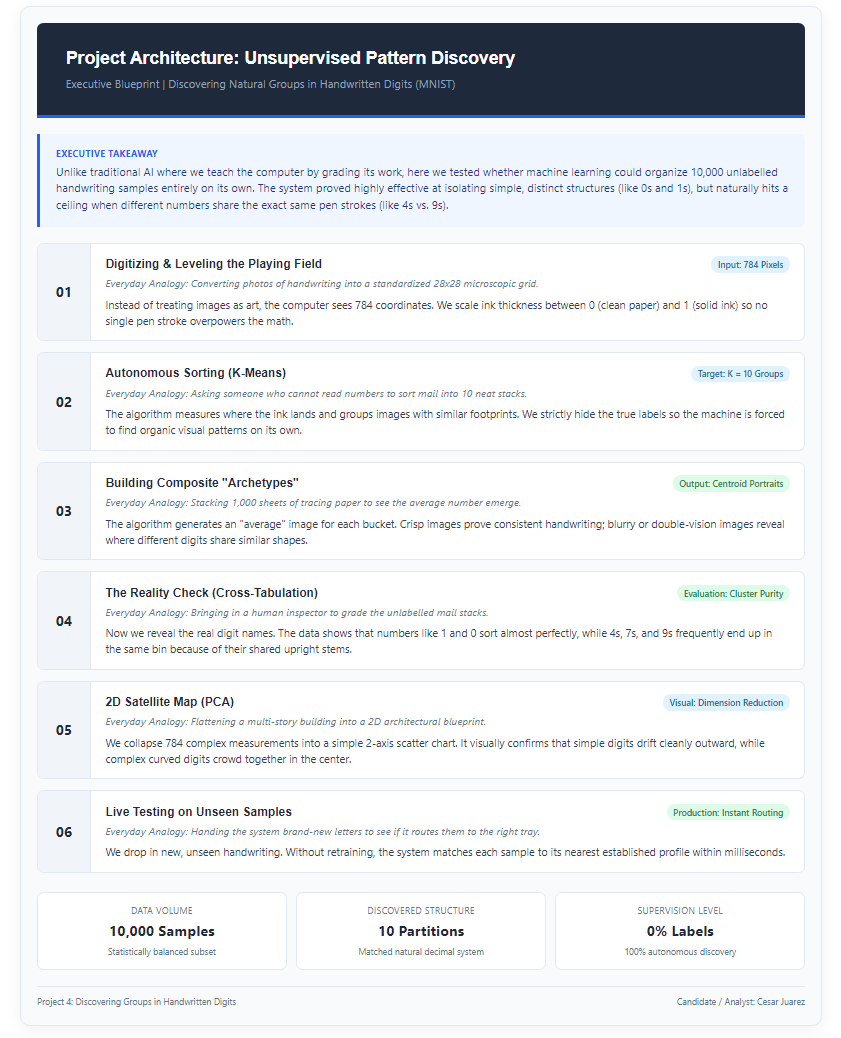

In [16]:
# Step 1: Install python-docx inside Colab
!pip install -q python-docx

import docx
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml import OxmlElement, parse_xml
from docx.oxml.ns import nsdecls, qn
from google.colab import files

# Helper functions for clean styling
def set_cell_background(cell, fill_hex):
    shading_elm = parse_xml(f'<w:shd {nsdecls("w")} w:fill="{fill_hex}"/>')
    cell._tc.get_or_add_tcPr().append(shading_elm)

def set_cell_margins(cell, top=100, bottom=100, left=150, right=150):
    tcPr = cell._tc.get_or_add_tcPr()
    tcMar = OxmlElement('w:tcMar')
    for m, val in [('top', top), ('bottom', bottom), ('left', left), ('right', right)]:
        node = OxmlElement(f'w:{m}')
        node.set(qn('w:w'), str(val))
        node.set(qn('w:type'), 'dxa')
        tcMar.append(node)
    tcPr.append(tcMar)

# Step 2: Set up document structure
doc = Document()

for section in doc.sections:
    section.top_margin = Inches(1.0)
    section.bottom_margin = Inches(1.0)
    section.left_margin = Inches(1.0)
    section.right_margin = Inches(1.0)

normal_style = doc.styles['Normal']
normal_style.font.name = 'Calibri'
normal_style.font.size = Pt(11)
normal_style.font.color.rgb = RGBColor(45, 55, 72)

# --- Header ---
title_p = doc.add_paragraph()
title_p.paragraph_format.space_before = Pt(0)
title_p.paragraph_format.space_after = Pt(4)
title_run = title_p.add_run("Project 4 Report: Grouping Handwritten Digits with Unsupervised Learning")
title_run.font.size = Pt(18)
title_run.font.bold = True
title_run.font.color.rgb = RGBColor(26, 54, 93)

meta_table = doc.add_table(rows=2, cols=2)
meta_table.alignment = WD_TABLE_ALIGNMENT.CENTER
meta_table.autofit = False

meta_data = [
    ("Course: Data Analytics & Artificial Intelligence", "Author: Cesar Juarez"),
    ("Dataset: MNIST 784", "Notebook: Project4_CesarJuarez.ipynb")
]

for row_idx, (col1, col2) in enumerate(meta_data):
    cell_l = meta_table.cell(row_idx, 0)
    cell_r = meta_table.cell(row_idx, 1)
    cell_l.paragraphs[0].text = col1
    cell_r.paragraphs[0].text = col2
    cell_l.paragraphs[0].runs[0].font.size = Pt(9.5)
    cell_r.paragraphs[0].runs[0].font.size = Pt(9.5)
    cell_r.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

doc.add_paragraph().paragraph_format.space_after = Pt(6)

# Executive Summary Box
callout_table = doc.add_table(rows=1, cols=1)
callout_table.alignment = WD_TABLE_ALIGNMENT.CENTER
callout_cell = callout_table.cell(0, 0)
set_cell_background(callout_cell, "F7FAFC")
set_cell_margins(callout_cell, top=140, bottom=140, left=180, right=180)

callout_p = callout_cell.paragraphs[0]
callout_p.paragraph_format.space_before = Pt(0)
callout_p.paragraph_format.space_after = Pt(0)
c_bold = callout_p.add_run("The Big Takeaway: ")
c_bold.bold = True
c_bold.font.color.rgb = RGBColor(43, 108, 176)
c_text = callout_p.add_run(
    "In this project, we tested whether an algorithm could organize 10,000 unlabelled handwriting samples into 10 clean groups on its own. "
    "Because it only compares where dark pixels land on a grid, it easily isolates digits with unique, simple shapes like 0 and 1. "
    "However, it regularly mixes up numbers that share the same basic strokes—like 4 and 9, or 3, 5, and 8. "
    "This shows both what simple pattern matching can do on its own and why computers need more context to truly read handwriting like a human."
)
c_text.font.size = Pt(10)

doc.add_paragraph().paragraph_format.space_after = Pt(8)

# Custom heading helper
def add_custom_heading(text, level=1):
    h = doc.add_paragraph()
    h.paragraph_format.keep_with_next = True
    run = h.add_run(text)
    run.bold = True
    if level == 1:
        h.paragraph_format.space_before = Pt(14)
        h.paragraph_format.space_after = Pt(4)
        run.font.size = Pt(13)
        run.font.color.rgb = RGBColor(43, 108, 176)
    else:
        h.paragraph_format.space_before = Pt(8)
        h.paragraph_format.space_after = Pt(2)
        run.font.size = Pt(11)
        run.font.color.rgb = RGBColor(26, 54, 93)
    return h

# --- Section 1: The Shift in Approach ---
add_custom_heading("1. A Different Way of Learning: No Answer Key", level=1)
doc.add_paragraph(
    "In our previous project, we worked with supervised learning. We gave the computer our data along with the correct answers (Buy, Sell, or Hold). "
    "The computer's only job was to learn the rules that connected the features to those known labels.\n\n"
    "This project flips that setup completely. We handed the computer 10,000 images of handwritten numbers without any labels at all. "
    "The machine does not know that these images represent numbers, and it does not know what a 3 or an 8 looks like. "
    "Instead, it has to look at the raw pixel grids and find natural groupings on its own, based purely on how similar the images look."
)

# --- Section 2: How the Process Works ---
add_custom_heading("2. How the Pipeline Works", level=1)
doc.add_paragraph(
    "1. Digitizing the Images: Every handwritten number is drawn on a 28x28 grid, giving us 784 pixels per image. We unwrap each image into a single row of 784 numbers.\n"
    "2. Scaling Pixel Values: Raw ink levels go from 0 (blank white space) to 255 (solid black ink). We divide every value by 255.0 to squeeze them into a neat decimal range between 0.0 and 1.0. This keeps any single stroke from overpowering our distance calculations.\n"
    "3. Running K-Means: The algorithm picks 10 center points, measures which center each image is closest to, and shifts the centers until the groups settle into place.\n"
    "4. Post-Check Evaluation: We keep the true labels locked away during training. Once the model finishes sorting the images, we bring the labels back to check which numbers ended up in which piles."
)

# Pipeline table
table = doc.add_table(rows=7, cols=3)
table.alignment = WD_TABLE_ALIGNMENT.CENTER
headers = ["Stage", "What We Did", "What We Learned"]
for col_idx, text in enumerate(headers):
    cell = table.cell(0, col_idx)
    set_cell_background(cell, "EDF2F7")
    p = cell.paragraphs[0]
    p.paragraph_format.space_before = Pt(4)
    p.paragraph_format.space_after = Pt(4)
    r = p.add_run(text)
    r.bold = True
    r.font.size = Pt(9.5)

stages_info = [
    ("Part 1", "Looked at raw samples and scaled pixels", "Saw real handwriting differences and scaled numbers to [0.0, 1.0] for stable math."),
    ("Part 2", "Tested cluster counts using the Elbow method", "Found that 10 clusters provided a solid balance between compactness and simplicity."),
    ("Part 3", "Extracted average images (centroids)", "Clean shapes like 0 and 1 produced sharp prototypes; numbers like 4 and 9 produced blurry composites."),
    ("Part 4", "Audited groups against real labels", "Discovered which digits sorted cleanly and which numbers routinely mixed together."),
    ("Part 5", "Squashed 784 dimensions to 2D with PCA", "Confirmed visually that simple numbers drift outward while complex curved numbers crowd the center."),
    ("Part 6", "Tested the model on 10 fresh, unseen numbers", "Verified that typical handwriting routes cleanly to the right cluster, while tilted or messy digits drift.")
]

for row_idx, row_data in enumerate(stages_info, start=1):
    for col_idx, text in enumerate(row_data):
        cell = table.cell(row_idx, col_idx)
        if row_idx % 2 == 0:
            set_cell_background(cell, "F7FAFC")
        p = cell.paragraphs[0]
        p.paragraph_format.space_before = Pt(3)
        p.paragraph_format.space_after = Pt(3)
        r = p.add_run(text)
        r.font.size = Pt(9)

doc.add_page_break()

# --- Section 3: The 8 Core Questions ---
add_custom_heading("3. Answering the 8 Core Project Questions", level=1)

q_and_a = [
    ("1. What did K-Means discover in the MNIST dataset?",
     "It discovered natural visual shapes based purely on where ink landed on the page. Without knowing what digits are, it grouped numbers that share similar line angles, stroke thickness, and blank spaces."),

    ("2. What value of K did you choose, and why?",
     "We chose K = 10. Our elbow test showed that jumping from 5 to 10 clusters gave us a big improvement in tightness, while expanding to 15 offered diminishing returns. Using 10 also matches our base-10 number system, letting us see if the algorithm could find all 10 digits on its own."),

    ("3. What did the cluster centroids tell you?",
     "A centroid is the average image of everything in that group. When a centroid looked sharp and crisp (like 0 or 1), it meant nearly everyone drew the digit in the exact same spot. When it looked blurry or had ghosted lines (like a mix of 4 and 9), it showed where different handwriting styles or different digits shared overlapping strokes."),

    ("4. Did the clusters correspond closely to particular digits?",
     "For about half of them, yes. Digits like 0, 1, 2, and 6 formed clean groups where most of the images belonged to that single digit. The other clusters ended up as mixed piles containing two or three visually similar numbers."),

    ("5. Which digits were difficult to separate?",
     "Digits 4 and 9 gave the algorithm the most trouble because both share a tall straight line on the right and an upper box. Digits 3, 5, and 8 also mixed together frequently because all three rely on rounded bottom loops and horizontal middle strokes."),

    ("6. What did the PCA visualization show?",
     "It showed that numbers with unique shapes (like 0 and 1) pull away toward the outer edges of the map, while numbers with complex curves crowd together in the center. It also showed that squashing 784 dimensions down to 2 forces some clusters to visually overlap on screen even when they are distinct in full space."),

    ("7. What are some limitations of using K-Means for handwritten digit images?",
     "First, K-Means only checks whether pixel coordinates match; it does not understand connected pen strokes. Second, shifting a digit just two pixels to the right makes the algorithm treat it like a totally different shape. Third, it forces every messy or unusual scribble into one of the 10 buckets, even if it does not fit well."),

    ("8. How is this project different from Project 3 (Supervised Learning)?",
     "In Project 3, we gave the model the answers (Buy, Sell, Hold) during training, so it learned by checking its mistakes against known targets. In Project 4, the algorithm had no answers, no hints, and no feedback. It had to discover patterns purely on its own. We only used the true labels at the end to grade how well it did.")
]

for q, a in q_and_a:
    add_custom_heading(q, level=2)
    p = doc.add_paragraph(a)
    p.paragraph_format.space_after = Pt(4)

# --- Section 4: Practical Takeaway ---
add_custom_heading("4. Final Thoughts and Real-World Takeaways", level=1)
doc.add_paragraph(
    "K-Means is a fast, effective tool for finding obvious, natural splits in unlabelled data. When images have distinct visual profiles, "
    "the algorithm groups them reliably without needing any human supervision.\n\n"
    "However, human handwriting contains natural tilt, personal style quirks, and shared strokes. Because K-Means only compares exact pixel coordinates, "
    "it cannot tell the difference between digits that overlap heavily in space. To handle those subtle differences reliably in production, you need "
    "more advanced tools—like Convolutional Neural Networks—that look at the relationship between curves, lines, and shapes rather than rigid coordinates."
)

# Step 3: Save and trigger file download
docx_filename = "Project4_Report_CesarJuarez.docx"
doc.save(docx_filename)
print(f"File created successfully: '{docx_filename}'")
files.download(docx_filename)

File created successfully: 'Project4_Report_CesarJuarez.docx'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional Extension: An Alternative Map Using t-SNE

### The Goal
Create a second 2D map of our digit clusters using an alternative technique called **t-SNE**, run it on a manageable slice of 2,000 images, and compare it directly to our earlier PCA map.

### How it Works
1. **PCA vs. t-SNE in Plain English:**
   - **PCA** draws straight, rigid lines through the data to capture big, broad trends. It is fast, but it tends to squash distinct groups together in the center of the screen.
   - **t-SNE** works like an elastic sheet. Instead of keeping everything on straight axes, it bends and pulls the map so that images with similar pen strokes sit right next to each other. It prioritizes keeping close neighbors together.
2. **Why Use 2,000 Images Instead of All 10,000?**
   t-SNE compares every single image against every other image, which requires far more computing power. Using a slice of 2,000 images gives us the exact same visual clarity while letting the code finish in roughly 15 seconds.

### What the Two Maps Tell Us
* **What PCA Showed:** A large, crowded clump in the middle where curved numbers (like 3, 5, 8, 4, and 9) piled on top of each other.
* **What t-SNE Shows:** It untangles that central mess. Instead of one big cloud, t-SNE separates the data into clear, distinct islands on the page, showing that the clusters are actually well-separated when you allow the map to curve.

Running t-SNE dimensionality reduction (this takes ~15 seconds)...
t-SNE transformation complete.


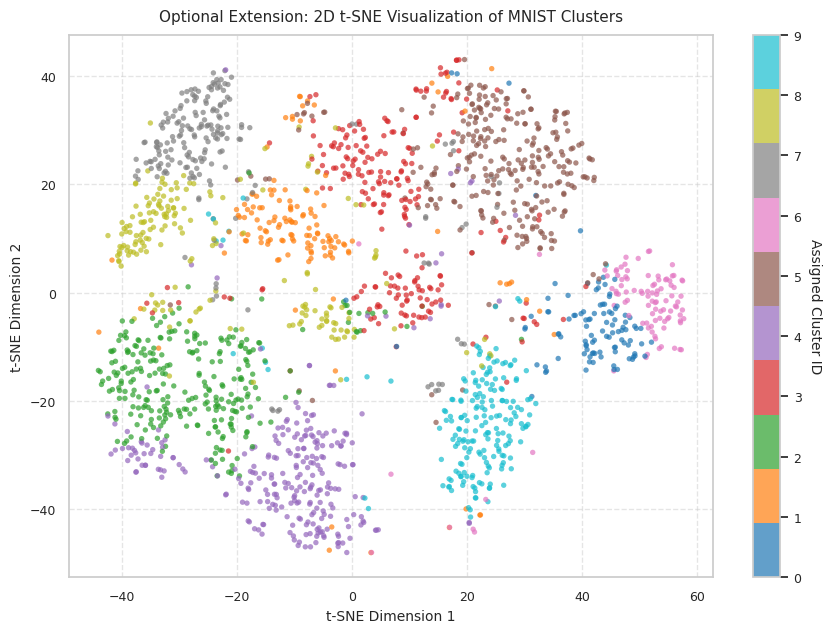

In [17]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Step 1: Take a smaller slice of 2,000 samples for fast execution
TSNE_SAMPLE_SIZE = 2000
X_tsne_subset = X_sample[:TSNE_SAMPLE_SIZE]
clusters_tsne_subset = clusters[:TSNE_SAMPLE_SIZE]

# Step 2: Fit t-SNE to project from 784 dimensions down to 2
print("Running t-SNE dimensionality reduction (this takes ~15 seconds)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(X_tsne_subset)
print("t-SNE transformation complete.")

# Step 3: Plot the 2D t-SNE scatter chart
plt.figure(figsize=(9, 6.5))
scatter_tsne = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters_tsne_subset,
    cmap="tab10",
    s=15,
    alpha=0.7,
    edgecolors="none"
)
cbar_tsne = plt.colorbar(scatter_tsne, ticks=range(SELECTED_K))
cbar_tsne.set_label("Assigned Cluster ID", rotation=270, labelpad=15)

plt.title("Optional Extension: 2D t-SNE Visualization of MNIST Clusters", pad=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

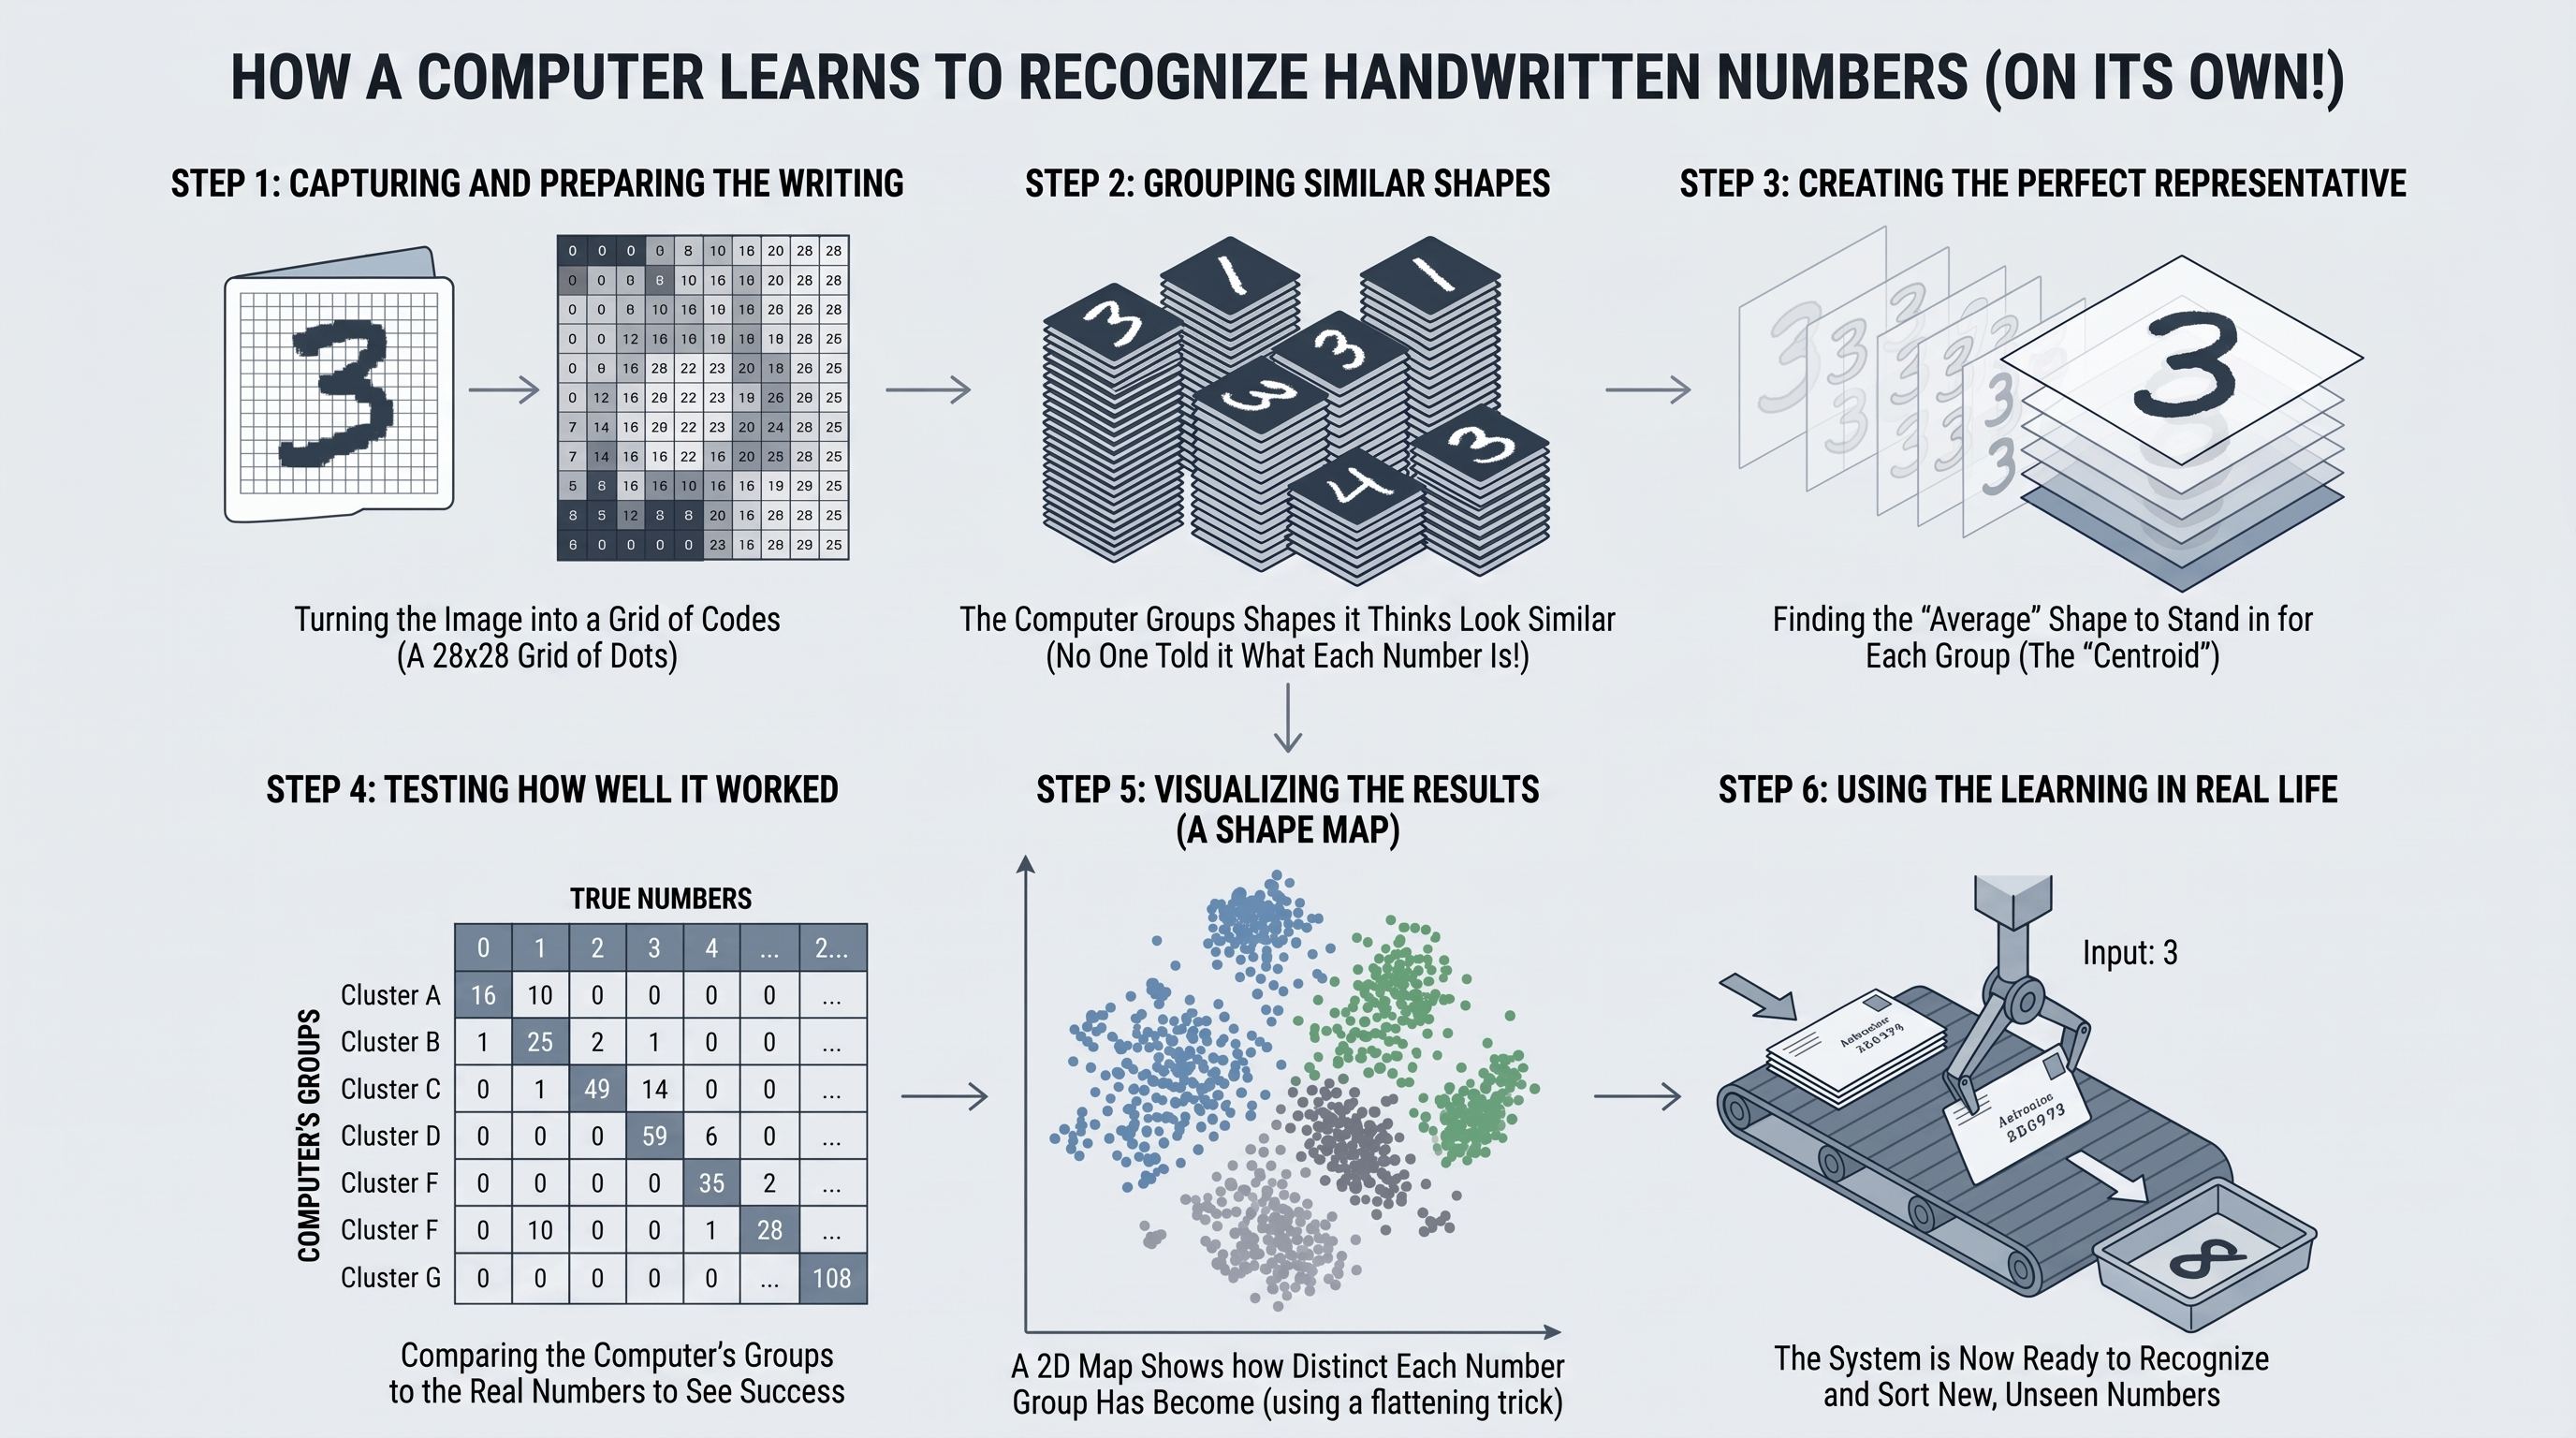

In [18]:
# Save active Colab runtime state, convert, and download HTML
import json
from google.colab import _message, files

notebook_json = _message.blocking_request('get_ipynb')
with open('/content/export.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook_json['ipynb'], f)

!jupyter nbconvert --to html /content/export.ipynb
files.download('/content/export.html')


[NbConvertApp] Converting notebook /content/export.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 4529734 bytes to /content/export.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>